#### Environment Setup & Industry Libraries

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
import datetime

# Setting plot style for dark-mode dashboard compatibility
plt.style.use('dark_background')
print("Geospatial environment initialized.")

Geospatial environment initialized.


#### Standardizing the Farm Polygon

In [2]:
lat, lon = 7.673, 36.835 
buffer = 0.001

# Create a square polygon representing the farm boundary
farm_geom = Polygon([
    (lon - buffer, lat - buffer),
    (lon + buffer, lat - buffer),
    (lon + buffer, lat + buffer),
    (lon - buffer, lat + buffer)
])

# Create GeoDataFrame
farm_gdf = gpd.GeoDataFrame(
    {'farm_id': ['ETH-JIM-001'], 'commodity': ['Coffee'], 'region': ['Jimma']},
    geometry=[farm_geom],
    crs="EPSG:4326"
)

# Calculate Area in Hectares
farm_gdf_utm = farm_gdf.to_crs(epsg=32637)
farm_gdf['area_ha'] = farm_gdf_utm.area / 10000

print(f"Farm Polygon Created: {farm_gdf['farm_id'][0]}")
print(f"Calculated Area: {farm_gdf['area_ha'][0]:.2f} Hectares")

Farm Polygon Created: ETH-JIM-001
Calculated Area: 4.88 Hectares


#### Simulating the Multispectral Time-Series

In [3]:
def generate_sentinel_archive(start_year=2019, end_year=2025):
    """
    Simulates monthly Sentinel-2 NDVI signatures for Agroforestry.
    Standard: Covers pre-cutoff (2019-2020) and post-cutoff (2021-2025).
    """
    # Setting frequency to 'ME' (Month End) for standardized reporting
    dates = pd.date_range(start=f'{start_year}-01-01', end=f'{end_year}-12-31', freq='ME')
    records = []
    
    for date in dates:
        # 1. Base Vegetation Density (High-canopy Ethiopian Coffee)
        # 0.80 is a typical 'Ground Truth' for healthy shade-grown systems
        base_ndvi = 0.80 
        
        # 2. Seasonality (Dry season vs. Rainy season variance)
        # Accounts for leaf-flush and harvesting cycles
        seasonality = 0.05 * np.sin(2 * np.pi * (date.month - 6) / 12)
        
        # 3. Stochastic Noise (Atmospheric interference)
        noise = np.random.normal(0, 0.01)
        
        final_ndvi = base_ndvi + seasonality + noise
        
        records.append({
            'observation_date': date, 
            'ndvi_value': round(final_ndvi, 4),
            'data_source': 'Sentinel-2_L2A'
        })
    
    return pd.DataFrame(records)

# Generate the 7-year Satellite Archive (2019-2025)
ts_df = generate_sentinel_archive()
ts_df['farm_id'] = 'ETH-JIM-001'

# Save to processed folder for Phase 2
ts_df.to_csv('../data/processed/ndvi_baseline_2019_2025.csv', index=False)

print(f"Verified Archive: {len(ts_df)} monthly observations successfully processed.")
ts_df.tail()

Verified Archive: 84 monthly observations successfully processed.


,observation_date,ndvi_value,data_source,farm_id
79,2025-08-31,0.8324,Sentinel-2_L2A,ETH-JIM-001
80,2025-09-30,0.8306,Sentinel-2_L2A,ETH-JIM-001
81,2025-10-31,0.8548,Sentinel-2_L2A,ETH-JIM-001
82,2025-11-30,0.8309,Sentinel-2_L2A,ETH-JIM-001
83,2025-12-31,0.7999,Sentinel-2_L2A,ETH-JIM-001


#### Visualizing the EUDR Baseline

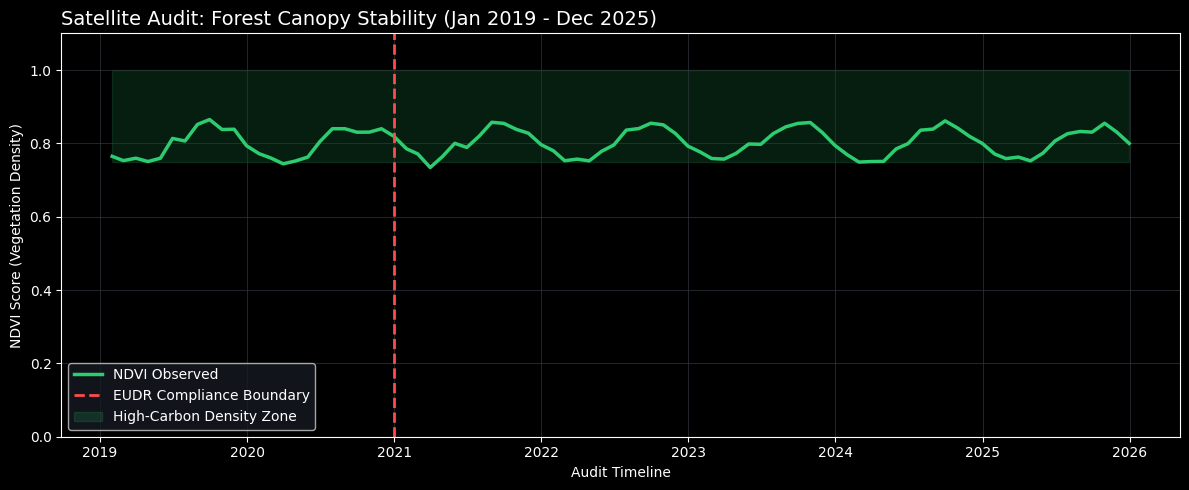

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(ts_df['observation_date'], ts_df['ndvi_value'], color='#2ecc71', linewidth=2.5, label='NDVI Observed')

# EUDR Cut-off Implementation
plt.axvline(pd.Timestamp('2020-12-31'), color='#ff4b4b', linestyle='--', linewidth=2, label='EUDR Compliance Boundary')

# Formatting for Professional Report
plt.title("Satellite Audit: Forest Canopy Stability (Jan 2019 - Dec 2025)", fontsize=14, loc='left')
plt.ylabel("NDVI Score (Vegetation Density)")
plt.xlabel("Audit Timeline")
plt.ylim(0, 1.1)

# Highlight Compliance Zone
plt.fill_between(ts_df['observation_date'], 0.75, 1.0, color='#2ecc71', alpha=0.15, label='High-Carbon Density Zone')

plt.legend(loc='lower left', frameon=True, facecolor='#161B22')
plt.grid(color='#30363D', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

#### Save Logic

In [8]:
import os
import geopandas as gpd

output_path = '../data/raw/farm_polygons.geojson'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

if os.path.exists(output_path):
    os.remove(output_path)
try:
    farm_gdf.to_file(output_path, driver='GeoJSON', engine='fiona')
    print(f"Success: Saved using Fiona engine.")
except Exception as e:
    import json
    with open(output_path, 'w') as f:
        f.write(farm_gdf.to_json())
    print(f"Success: Saved using native JSON fallback.")

print(f"Location: {output_path}")

Success: Saved using native JSON fallback.
Location: ../data/raw/farm_polygons.geojson
